In [11]:
from langchain_groq.chat_models import ChatGroq
from langchain_core.messages import AnyMessage, AIMessage, HumanMessage
from langchain_core.messages import BaseMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

from dotenv import load_dotenv
from typing import TypedDict, Annotated
from typing import Annotated

import os

load_dotenv()

True

In [12]:
# llm
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_MODEL = os.getenv("GROQ_MODEL")

if not GROQ_API_KEY or not GROQ_MODEL:
    raise RuntimeError("GROQ_API_KEY / GROQ_MODEL missing from env")

llm = ChatGroq(model=GROQ_MODEL, api_key=GROQ_API_KEY)

In [13]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [14]:
def chat_node(state: ChatState):
    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}


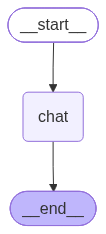

In [15]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# checkepointer is required for interrupt
memory = MemorySaver()

app = builder.compile(checkpointer=memory)

app

In [49]:
# create a new thread id for this conversation
config = ({"configurable": {"thread_id": "1234"}})

# step-1: User ask question
initial_input = {
        "messages": [HumanMessage(content= "Write a 6 lines love poetry")]
}

# invoke the graph for the first time
result = app.invoke(initial_input, config=config)

result

{'messages': [HumanMessage(content='Explain HITL in very simple term?', additional_kwargs={}, response_metadata={}, id='475e56e8-ebf9-4141-b9dd-10087b398b1d'),
  HumanMessage(content='Explain HITL in very simple term?', additional_kwargs={}, response_metadata={}, id='aef5ba3f-f92c-4c43-8697-8e4e7de567ba'),
  HumanMessage(content='Explain HITL in very simple term?', additional_kwargs={}, response_metadata={}, id='d6491942-b2ef-4eff-8215-4b899ffc68cd'),
  HumanMessage(content='Explain HITL in very simple term?', additional_kwargs={}, response_metadata={}, id='ed672556-5af1-44af-af2a-a507d80fefbd'),
  AIMessage(content='**Human‑In‑The‑Loop (HITL)** is a way of building or running a computer system where a person is kept in the process to check, guide, or correct what the machine does.\n\n---\n\n### Very simple picture\n\n| Machine alone | Human‑In‑The‑Loop |\n|---------------|-------------------|\n| **Robot** → decides everything on its own → may make mistakes. | **Robot** → does its job 

In [50]:
message = result["__interrupt__"][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Write a 6 lines love poetry',
 'instruction': 'Approve this question? yes/no'}

In [51]:
user_input = input(f"Backen Message:{message}\n\nApprove this question? (y/n).")

user_input

'yes'

In [52]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [53]:
final_result["messages"][-1].content

"In the hush of twilight, your smile ignites,  \nA whispered promise in the evening's sigh.  \nYour eyes, twin stars, guide my wandering heart,  \nEach beat a soft echo of you, close and near.  \nLove drifts like petals on a gentle breeze,  \nAnd in its hush, I find forever here."